# Preprocessing of Dataset

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
data=pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

## 1. Reading data by Pandas Simple Operations

In [41]:
data.sample()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3921,Toyota Innova 2.5 EV Diesel MS 7 Str BSIII,2010,400000,120000,Diesel,Individual,Manual,First Owner


In [42]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [43]:
data.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


## Checking Data Types  and Information

In [44]:
data.dtypes

name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

In [45]:
data.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


## 2. Data Cleaning

## Checking Null Values

In [47]:
data.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

__Separate numeric and non-numeric columns__

In [48]:
numeric_cols=data.select_dtypes(include=[np.number])
non_numeric_cols=data.select_dtypes(exclude=[np.number])

__Fill missing values in numeric columns with the mean and non_numeric by mode__

In [49]:
numeric_cols.fillna(numeric_cols.mean(),inplace=True)
non_numeric_cols.fillna(non_numeric_cols.mode(),inplace=True)


__Combine back with non-numeric columns__

In [50]:
data=pd.concat([numeric_cols,non_numeric_cols],axis=1)

In [51]:
data.isnull().sum()

year             0
selling_price    0
km_driven        0
name             0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

## Droping Missing Values and Duplicate values


__In this case there is no missing value column so we do not do this process__

In [52]:
# data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

## Checking shape of data

In [53]:
data.shape

(3577, 8)

# 3. Checking Outliers

__Calculate IQR__

- __Filter out outliers__

In [54]:
numeric_cols = data.select_dtypes(include=['float64']).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = mask & data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]


__Visualizing the data before outlier removal__

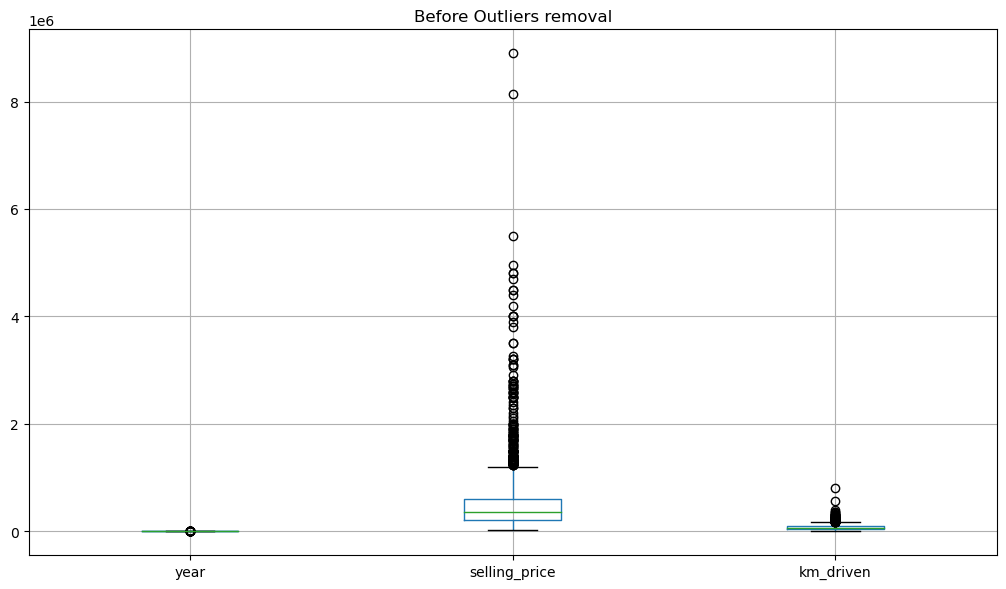

In [55]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
data.boxplot()
plt.title("Before Outliers removal")
plt.tight_layout()
plt.show()

## Removing Outliers

__Visualizing the data after outlier removal__

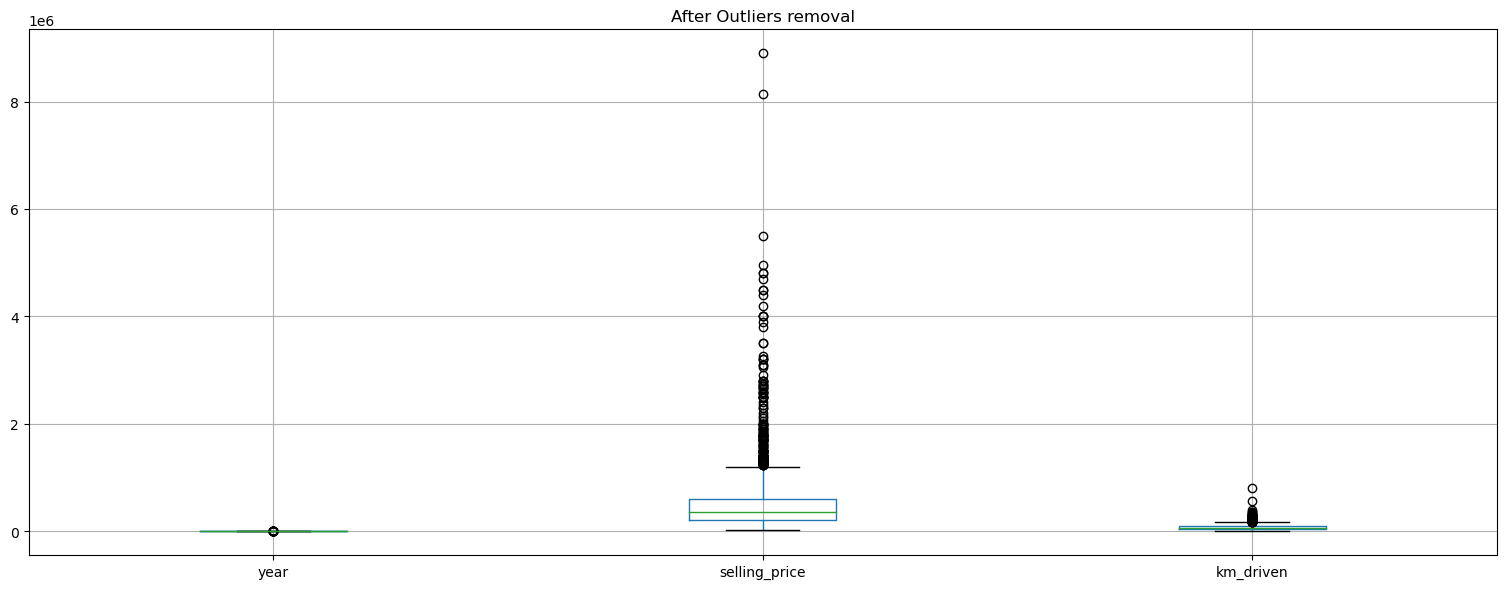

In [56]:
plt.figure(figsize=(30,6))
plt.subplot(1,2,1)
data_cleaned.boxplot()
plt.title("After Outliers removal")
plt.tight_layout()
plt.show()

# 4. Data Transformation

## Normalization

__Defination:__
- Values are scaled to a fixed range, typically [0, 1].
- Compresses or stretches the data to fit within the specified range, potentially altering the original distribution.

__Use Cases:__

- Suitable for distance-based algorithms, like k-nearest neighbors and neural networks.

In [57]:
from sklearn.preprocessing import MinMaxScaler
numeric_cols = data.select_dtypes(include=['float64']).columns
numeric_data = data[numeric_cols]
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_data = pd.DataFrame(scaled_numeric_data, columns=numeric_cols)
non_numeric_data = data.drop(columns=numeric_cols).reset_index(drop=True)
scaled_data = pd.concat([scaled_numeric_data, non_numeric_data], axis=1)
print(scaled_data.shape)
print()
print('*' * 60)
scaled_data.head()

ValueError: at least one array or dtype is required

## Strandarization

__Defination:__
- Values are rescaled to have a mean of 0 and a standard deviation of 1.
- Preserves the shape of the original distribution but changes the scale.

__Use Cases:__
- Standardization: Suitable for algorithms that assume a normal distribution, like linear regression and logistic regression.


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

C:\Users\abdul\AppData\Local\Temp\ipykernel_8688\3951702090.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\abdul\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


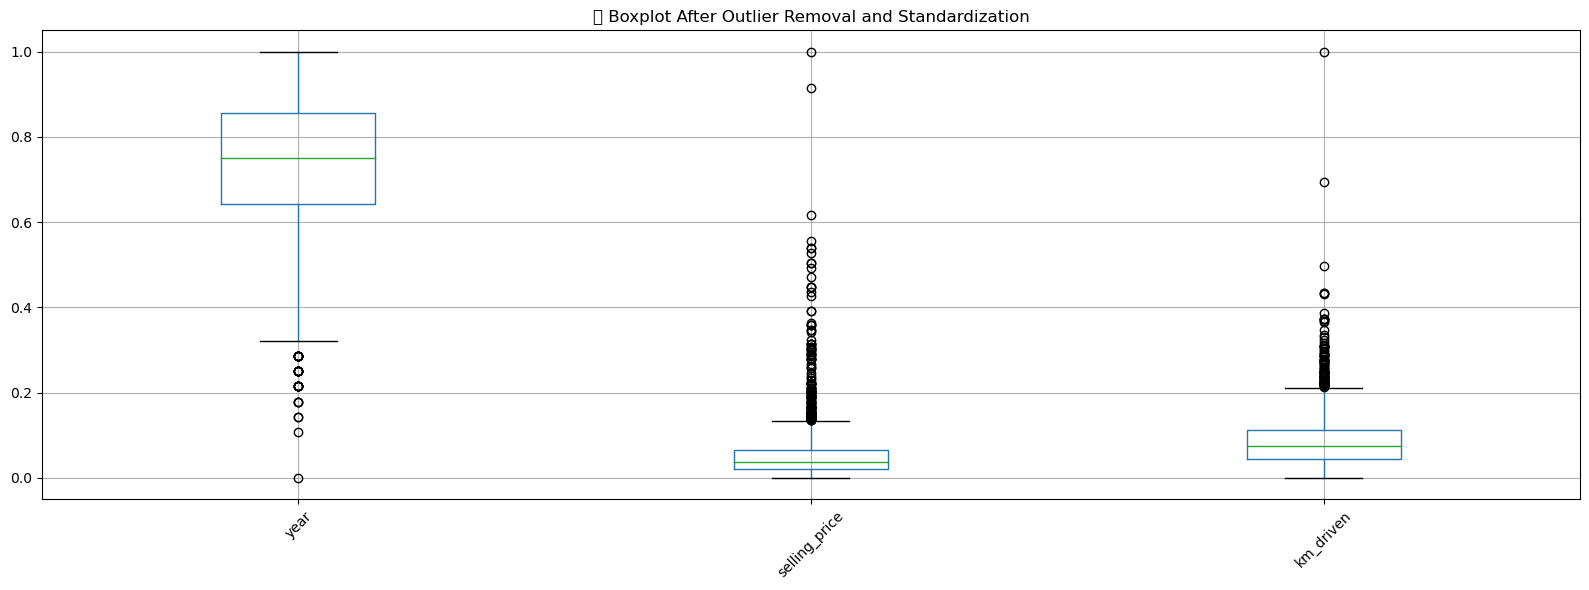

In [58]:
numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
data_scaled = pd.DataFrame(scaler.fit_transform(data_cleaned[numeric_cols]), columns=numeric_cols)
plt.figure(figsize=(16, 6))
data_scaled.boxplot()
plt.title("📊 Boxplot After Outlier Removal and Standardization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()